# XGBoost Model

In [103]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier
from functools import reduce
import pyarrow.parquet as pq
import re
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

In [104]:
#Import silver dataset

table = pq.read_table(r"C:\Users\omarl\Downloads\silver_layer_longitudinal.parquet")
df = table.to_pandas()

In [105]:
#Print the target variable distribution
print(df.shape)
print(df["ATSEG"].isna().sum())
print(df["ATSEG"].value_counts(dropna=False))

(1800066, 76)
776752
ATSEG
NaN      776752
SEG_A    550916
SEG_B    288014
SEG_C    184384
Name: count, dtype: int64


In [106]:
#Separate labeled and unlabeled data
df_labeled = df[df["ATSEG"].notna()].copy()
df_unlabeled = df[df["ATSEG"].isna()].copy()

print("Labeled shape:", df_labeled.shape)
print("Unlabeled shape:", df_unlabeled.shape)

Labeled shape: (1023314, 76)
Unlabeled shape: (776752, 76)


## Target variable distribution

In [107]:
#Show percentage of each class in the target variable
target_dist = df_labeled["ATSEG"].value_counts()
target_pct = df_labeled["ATSEG"].value_counts(normalize=True) * 100

display(pd.DataFrame({
    "count": target_dist,
    "pct": target_pct.round(2)
}))

,count,pct
ATSEG,,
SEG_A,550916,53.84
SEG_B,288014,28.15
SEG_C,184384,18.02


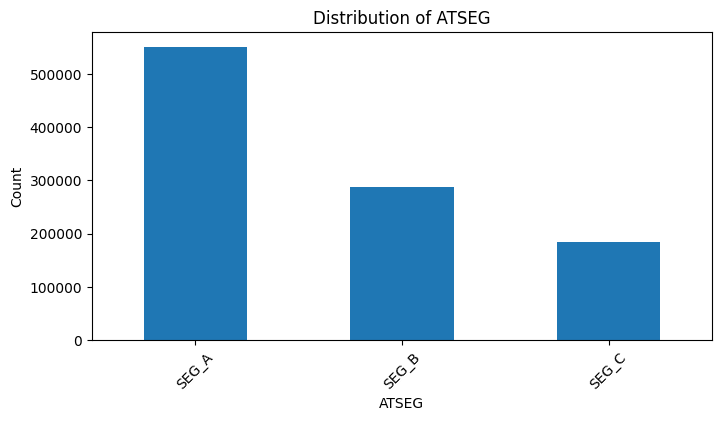

In [108]:
#Show distribution of the target variable
plt.figure(figsize=(8,4))
df_labeled["ATSEG"].value_counts().plot(kind="bar")
plt.title("Distribution of ATSEG")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Aggregate features

In [109]:
df_model=df.copy()
#Keep only tagged data for training the model
df_model=df_model[df_model['ATSEG'].notna()].copy()

#Temporal ordering of the data
df_model=df_model.sort_values(["NUEVO_ID","WEEK_ID"]).reset_index(drop=True)
df_model.head()

,NUEVO_ID,WEEK_ID,UC_TRX,ORAL_TRX,IL23_TRX,BRAND1_TRX,BRAND2_TRX,UC_NRX,ORAL_NRX,IL23_NRX,...,"(2020, 2030]",ATSEG,ATSEG_RAW,ATSEG_HCP,IS_LABELED_HCP,WEEK_IDX,SPECIALTY_GROUP,STATE_GROUP,AGE_RANGE_GROUP,HCP_FOLD
0,3,2024-01-05,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,SEG_A,SEG_A,SEG_A,1,0,GE,OTHER_STATE,"(1940, 1960]",1
1,3,2024-01-12,0.1652,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,SEG_A,SEG_A,SEG_A,1,1,GE,OTHER_STATE,"(1940, 1960]",1
2,3,2024-01-19,0.3304,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,SEG_A,SEG_A,SEG_A,1,2,GE,OTHER_STATE,"(1940, 1960]",1
3,3,2024-01-26,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,SEG_A,SEG_A,SEG_A,1,3,GE,OTHER_STATE,"(1940, 1960]",1
4,3,2024-02-02,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,SEG_A,SEG_A,SEG_A,1,4,GE,OTHER_STATE,"(1940, 1960]",1


In [110]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 1023314 entries, 0 to 1023313
Data columns (total 76 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   NUEVO_ID                  1023314 non-null  int64         
 1   WEEK_ID                   1023314 non-null  datetime64[ns]
 2   UC_TRX                    1023314 non-null  float32       
 3   ORAL_TRX                  1023314 non-null  float32       
 4   IL23_TRX                  1023314 non-null  float32       
 5   BRAND1_TRX                1023314 non-null  float32       
 6   BRAND2_TRX                1023314 non-null  float32       
 7   UC_NRX                    1023314 non-null  float32       
 8   ORAL_NRX                  1023314 non-null  float32       
 9   IL23_NRX                  1023314 non-null  float32       
 10  BRAND1_NRX                1023314 non-null  float32       
 11  BRAND2_NRX                1023314 non-null  float32       
 1

In [111]:
df_model.columns

Index(['NUEVO_ID', 'WEEK_ID', 'UC_TRX', 'ORAL_TRX', 'IL23_TRX', 'BRAND1_TRX',
       'BRAND2_TRX', 'UC_NRX', 'ORAL_NRX', 'IL23_NRX', 'BRAND1_NRX',
       'BRAND2_NRX', 'N_CLMBRAND3', 'N_CLMBRAND1', 'N_CLMBRAND4',
       'N_CLMBRAND2', 'N_CLMOTHERS', 'BRAND1_NBRX', 'BRAND2_NBRX', 'ORAL_NBRX',
       'IL23_NBRX', 'N_CLMBRAND3_NEW', 'N_CLMBRAND1_NEW', 'N_CLMBRAND4_NEW',
       'N_CLMBRAND2_NEW', 'N_CLMOTHERS_NEW', 'N_CLMBRAND3NEW_TO_BRAND',
       'N_CLMBRAND1_NEW_TO_BRAND', 'N_CLMBRAND4_NEW_TO_BRAND',
       'N_CLMBRAND2_NEW_TO_BRAND', 'N_CLMOTHERS_NEW_TO_BRAND', 'RTE',
       'SAMPLES', 'COPAY', 'DIRECTMAIL', 'SPK', 'DETAILS', 'UC_TRX_R4_16SUM',
       'ORAL_NBRX_R4_29SUM', 'IL23_NBRX_R4_29SUM', 'BRAND1_NTB_GIDX',
       'BRAND2_NTB_GIDX', 'BRAND1_T_GIDX', 'BRAND2_T_GIDX', 'YEAR', 'QTR',
       'YEAR_QTR', 'SPEC_GE', 'SPEC_GPFM', 'SPEC_IM', 'SPEC_NRP',
       'SPEC_OTHER_SPEC', 'SPEC_PHA', 'STATE_1', 'STATE_2', 'STATE_3',
       'STATE_4', 'STATE_5', 'STATE_6', 'STS_OTHER_STS', 'STATE_7

In [132]:
#Define column groups
id_col="NUEVO_ID"
time_col="WEEK_ID"
target_col="ATSEG"

key_numeric_cols=["UC_TRX", "ORAL_TRX", "IL23_TRX",
    "BRAND1_TRX", "BRAND1_NRX", "BRAND1_NBRX",
    "BRAND2_TRX", "BRAND2_NRX", 'BRAND2_NBRX',
    "DETAILS", "RTE", "SAMPLES", "COPAY", "DIRECTMAIL", "SPK"]

secondary_numeric_cols=["UC_NRX", "ORAL_NRX", "IL23_NRX",
    "ORAL_NBRX", "IL23_NBRX",
    "UC_TRX_R4_16SUM", "ORAL_NBRX_R4_29SUM", "IL23_NBRX_R4_29SUM",
    "BRAND1_NTB_GIDX", "BRAND2_NTB_GIDX",
    "BRAND1_T_GIDX", "BRAND2_T_GIDX"]

spec_cols=["SPEC_GE", "SPEC_GPFM", "SPEC_IM", "SPEC_NRP", "SPEC_OTHER_SPEC", "SPEC_PHA"]
state_cols=["STATE_1", "STATE_2", "STATE_3", "STATE_4", "STATE_5", "STATE_6", "STATE_7", "STATE_8", "STS_OTHER_STS"]
age_cols= ["(1940, 1960]", "(1960, 1980]", "(1980, 2000]", "(2000, 2020]", "(2020, 2030]"]
claim_cols = [
    "N_CLMBRAND1", "N_CLMBRAND2", "N_CLMOTHERS",
    "N_CLMBRAND1_NEW", "N_CLMBRAND2_NEW", "N_CLMOTHERS_NEW",
    "N_CLMBRAND1_NEW_TO_BRAND", "N_CLMBRAND2_NEW_TO_BRAND", "N_CLMOTHERS_NEW_TO_BRAND"
]

profile_cols=spec_cols + state_cols + age_cols

In [133]:
#Keep only columns that are in the dataset
key_numeric_cols = [c for c in key_numeric_cols if c in df_model.columns]
secondary_numeric_cols = [c for c in secondary_numeric_cols if c in df_model.columns]
profile_cols = [c for c in profile_cols if c in df_model.columns]
claim_cols = [c for c in claim_cols if c in df_model.columns]

In [114]:
#Aggregation functions
def last_non_null(x):
    x=x.dropna()
    return x.iloc[-1] if len(x)>0 else np.nan

def last_n_mean(x, n=4):
    x=x.dropna()
    return x.iloc[-n:].mean() if len(x)>0 else np.nan

def active_weeks(x):
    return (x.fillna(0)>0).sum()

def active_ratio(x):
    if len(x)==0:
        return np.nan
    return (x.fillna(0)>0).mean()

def recent_vs_mean(x, n=4):
    x_nonnull=x.dropna()
    if len(x_nonnull)==0:
        return np.nan
    overall_mean = x_nonnull.mean()
    recent_mean = x_nonnull.iloc[-n:].mean()
    return recent_mean-overall_mean

def recent_vs_mean_ratio(x, n=4):
    x_nonnull=x.dropna()
    if len(x_nonnull)==0:
        return np.nan
    overall_mean = x_nonnull.mean()
    recent_mean = x_nonnull.iloc[-n:].mean()
    if overall_mean==0:
        return np.nan
    return recent_mean/overall_mean

In [115]:
#Aggregate key numeric features by doctor
doctor_groups=df_model.groupby(id_col)

key_agg_parts=[]

for col in key_numeric_cols:
    tmp=doctor_groups[col].agg(
        mean="mean",
        median="median",
        std="std",
        max="max",
        sum="sum",
        last=last_non_null,
        active_weeks=active_weeks,
        active_ratio=active_ratio
    ).reset_index()

    #Rename columns
    tmp=tmp.rename(columns={
        "mean": f"{col}_mean",
        "median": f"{col}_median",
        "std": f"{col}_std",
        "max": f"{col}_max",
        "sum": f"{col}_sum",
        "last": f"{col}_last",
        "active_weeks": f"{col}_active_weeks",
        "active_ratio": f"{col}_active_ratio"
    })

    extra_last4 = doctor_groups[col].apply(lambda x: last_n_mean(x, 4)).reset_index(name=f"{col}_last4_mean")
    extra_recent_diff = doctor_groups[col].apply(lambda x: recent_vs_mean(x, 4)).reset_index(name=f"{col}_recent_vs_mean")
    extra_recent_ratio = doctor_groups[col].apply(lambda x: recent_vs_mean_ratio(x, 4)).reset_index(name=f"{col}_recent_vs_mean_ratio")

    tmp = tmp.merge(extra_last4, on=id_col, how="left")
    tmp = tmp.merge(extra_recent_diff, on=id_col, how="left")
    tmp = tmp.merge(extra_recent_ratio, on=id_col, how="left")
    key_agg_parts.append(tmp)

In [116]:
#Merge all aggregated parts into a single dataframe
doctor_key_features = reduce(
    lambda left, right: left.merge(right, on=id_col, how="outer"),
    key_agg_parts
)

doctor_key_features.head()

,NUEVO_ID,UC_TRX_mean,UC_TRX_median,UC_TRX_std,UC_TRX_max,UC_TRX_sum,UC_TRX_last,UC_TRX_active_weeks,UC_TRX_active_ratio,UC_TRX_last4_mean,...,SPK_median,SPK_std,SPK_max,SPK_sum,SPK_last,SPK_active_weeks,SPK_active_ratio,SPK_last4_mean,SPK_recent_vs_mean,SPK_recent_vs_mean_ratio
0,3,0.192200,0.1652,0.167927,0.6610,16.529200,0.4966,61,0.709302,0.12415,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,NaN
1,11,0.080474,0.0000,0.202373,1.3842,6.920800,0.0000,19,0.220930,0.00000,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,NaN
2,18,0.397300,0.3922,0.283645,1.7452,34.167801,0.6152,74,0.860465,0.28995,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,NaN
3,19,0.059123,0.0000,0.154884,0.9384,5.084600,0.0000,18,0.209302,0.00000,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,NaN
4,20,0.089442,0.0000,0.155311,0.7024,7.692000,0.1612,28,0.325581,0.08930,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,NaN


In [117]:
#Aggregate secondary numeric features by doctor
secondary_agg_parts = []

for col in secondary_numeric_cols:
    tmp = doctor_groups[col].agg(
        mean="mean",
        median="median",
        last=last_non_null
    ).reset_index()
    
    tmp = tmp.rename(columns={
        "mean": f"{col}_mean",
        "median": f"{col}_median",
        "last": f"{col}_last"
    })
    
    secondary_agg_parts.append(tmp)

if len(secondary_agg_parts) > 0:
    doctor_secondary_features = reduce(
        lambda left, right: left.merge(right, on=id_col, how="outer"),
        secondary_agg_parts
    )
else:
    doctor_secondary_features = pd.DataFrame({id_col: df_model[id_col].unique()})

In [118]:
#Aggregate profile features by doctor
if len(profile_cols) > 0:
    doctor_profile = doctor_groups[profile_cols].max().reset_index()
else:
    doctor_profile = pd.DataFrame({id_col: df_model[id_col].unique()})

In [119]:
#Aggregate target variable by doctor using mode (most frequent value)
doctor_target = doctor_groups[target_col].agg(lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0]).reset_index()

In [120]:
#Aggregate number of weeks observed for each doctor
doctor_general = doctor_groups.agg(
    n_weeks_observed=(time_col, "nunique")
).reset_index()

In [121]:
#Combine all aggregated features into a single dataframe
if "BRAND1_TRX" in df_model.columns and "UC_TRX" in df_model.columns:
    df_model["brand1_share_uc_row"] = df_model["BRAND1_TRX"] / df_model["UC_TRX"].replace(0, np.nan)
else:
    df_model["brand1_share_uc_row"] = np.nan

In [122]:
#Aggregate brand1 share of UC by doctor using mean, median and last value
doctor_share = doctor_groups["brand1_share_uc_row"].agg(
    brand1_share_uc_mean="mean",
    brand1_share_uc_median="median",
    brand1_share_uc_last=last_non_null
).reset_index()

In [123]:
#Merge all doctor-level features into a single dataframe
engagement_present = [c for c in ["DETAILS", "RTE", "SAMPLES", "COPAY", "DIRECTMAIL", "SPK"] if c in df_model.columns]

if len(engagement_present) > 0:
    df_model["engagement_total_row"] = df_model[engagement_present].fillna(0).sum(axis=1)
else:
    df_model["engagement_total_row"] = 0

In [124]:
#Aggregate total engagement by doctor
doctor_eng_total = doctor_groups["engagement_total_row"].agg(
    engagement_total_mean="mean",
    engagement_total_sum="sum",
    engagement_total_last=last_non_null,
    engagement_total_active_ratio=active_ratio
).reset_index()

doctor_eng_total_last4 = doctor_groups["engagement_total_row"].apply(
    lambda x: last_n_mean(x, 4)
).reset_index(name="engagement_total_last4_mean")

doctor_eng_total_recent = doctor_groups["engagement_total_row"].apply(
    lambda x: recent_vs_mean(x, 4)
).reset_index(name="engagement_total_recent_vs_mean")

doctor_eng_total = doctor_eng_total.merge(doctor_eng_total_last4, on=id_col, how="left")
doctor_eng_total = doctor_eng_total.merge(doctor_eng_total_recent, on=id_col, how="left")

In [134]:
claim_agg_parts = []

for col in claim_cols:
    tmp = doctor_groups[col].agg(
        mean="mean",
        sum="sum",
        last=last_non_null,
        active_ratio=active_ratio
    ).reset_index()

    tmp = tmp.rename(columns={
        "mean": f"{col}_mean",
        "sum": f"{col}_sum",
        "last": f"{col}_last",
        "active_ratio": f"{col}_active_ratio"
    })

    claim_last4 = doctor_groups[col].apply(
        lambda x: last_n_mean(x, 4)
    ).reset_index(name=f"{col}_last4_mean")

    tmp = tmp.merge(claim_last4, on=id_col, how="left")
    claim_agg_parts.append(tmp)

if len(claim_agg_parts) > 0:
    doctor_claim_features = reduce(
        lambda left, right: left.merge(right, on=id_col, how="outer"),
        claim_agg_parts
    )
else:
    doctor_claim_features = pd.DataFrame({id_col: df_model[id_col].unique()})

In [322]:
claim_features = [
    "N_CLMBRAND2_mean",
    "N_CLMBRAND2_sum",
    "N_CLMBRAND2_active_ratio",
    "N_CLMBRAND2_NEW_mean",
    "N_CLMBRAND2_NEW_sum",
    "N_CLMBRAND2_NEW_TO_BRAND_mean",
    "N_CLMBRAND2_NEW_TO_BRAND_sum",

    "N_CLMOTHERS_NEW_mean",
    "N_CLMOTHERS_NEW_sum",
    "N_CLMOTHERS_NEW_TO_BRAND_mean",
    "N_CLMOTHERS_NEW_TO_BRAND_sum"
]

In [319]:
#Merge all aggregated parts into a single dataframe
doctor_model_df = (
    doctor_general
    .merge(doctor_profile, on=id_col, how="left")
    .merge(doctor_key_features, on=id_col, how="left")
    .merge(doctor_secondary_features, on=id_col, how="left")
    .merge(doctor_claim_features, on=id_col, how="left")
    .merge(doctor_share, on=id_col, how="left")
    .merge(doctor_eng_total, on=id_col, how="left")
    .merge(doctor_target, on=id_col, how="left")
)

doctor_model_df.head()
print(doctor_model_df.shape)

(11899, 278)


In [281]:
doctor_model_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11899 entries, 0 to 11898
Columns: 233 entries, NUEVO_ID to ATSEG
dtypes: float32(180), float64(15), int64(17), int8(20), str(1)
memory usage: 11.5 MB


In [320]:
doctor_model_df.isna().mean().sort_values(ascending=False).head(20)

COPAY_recent_vs_mean_ratio          0.932011
BRAND1_NRX_recent_vs_mean_ratio     0.926464
BRAND1_NBRX_recent_vs_mean_ratio    0.925876
BRAND1_TRX_recent_vs_mean_ratio     0.923943
BRAND2_NBRX_recent_vs_mean_ratio    0.901925
SPK_recent_vs_mean_ratio            0.900832
BRAND2_NRX_recent_vs_mean_ratio     0.848559
BRAND2_TRX_recent_vs_mean_ratio     0.838642
SAMPLES_recent_vs_mean_ratio        0.758803
RTE_recent_vs_mean_ratio            0.703168
IL23_TRX_recent_vs_mean_ratio       0.369863
ORAL_TRX_recent_vs_mean_ratio       0.278931
DIRECTMAIL_recent_vs_mean_ratio     0.254055
DETAILS_recent_vs_mean_ratio        0.236154
brand1_share_uc_mean                0.024204
brand1_share_uc_median              0.024204
brand1_share_uc_last                0.024204
UC_TRX_recent_vs_mean_ratio         0.024204
UC_NRX_mean                         0.000000
UC_NRX_median                       0.000000
dtype: float64

In [321]:
doctor_model_df[target_col].value_counts()

ATSEG
SEG_A    6406
SEG_B    3349
SEG_C    2144
Name: count, dtype: int64

In [318]:
print("Rows in doctor_model_df:", doctor_model_df.shape[0])
print("Unique doctors:", doctor_model_df["NUEVO_ID"].nunique())
print("Duplicated doctors:", doctor_model_df["NUEVO_ID"].duplicated().sum())

Rows in doctor_model_df: 11899
Unique doctors: 11899
Duplicated doctors: 0


## Preparation for modeling

In [434]:
# Define core features for the model
core_features = [
    "UC_TRX_mean", "UC_TRX_median", "UC_TRX_last4_mean", "UC_TRX_active_ratio",
    "ORAL_TRX_mean", "IL23_TRX_mean",
    
    "BRAND1_TRX_mean", "BRAND1_TRX_median", "BRAND1_TRX_std", "BRAND1_TRX_max",
    "BRAND1_TRX_last", "BRAND1_TRX_last4_mean", "BRAND1_TRX_active_ratio",
    
    "BRAND1_NRX_mean", "BRAND1_NRX_last", "BRAND1_NRX_last4_mean", "BRAND1_NRX_active_ratio",
    "BRAND1_NBRX_mean", "BRAND1_NBRX_last4_mean", "BRAND1_NBRX_active_ratio",
    
    "BRAND2_TRX_mean", "BRAND2_NRX_mean",
    
    "DETAILS_sum", "DETAILS_mean", "DETAILS_last4_mean", "DETAILS_active_ratio",
    "RTE_sum", "RTE_mean", "RTE_last4_mean", "RTE_active_ratio",
    "SAMPLES_sum", "SAMPLES_mean", "SAMPLES_active_ratio",
    "COPAY_sum", "DIRECTMAIL_sum", "SPK_sum",
    
    "engagement_total_sum", "engagement_total_mean",
    "engagement_total_last4_mean", "engagement_total_active_ratio",
    
    "brand1_share_uc_mean", "brand1_share_uc_median", "brand1_share_uc_last"
] + profile_cols 

core_features = [c for c in core_features if c in doctor_model_df.columns]
len(core_features)

63

In [435]:
# Prepare data for modeling
X = doctor_model_df[core_features].copy()
y = doctor_model_df[target_col].copy()

print(X.shape, y.shape)

(11899, 63) (11899,)


In [436]:
#Clean feature names to ensure they are valid for modeling
def clean_feature_name(col):
    col = str(col)
    col = col.replace("[", "")
    col = col.replace("]", "")
    col = col.replace("<", "")
    col = col.replace(">", "")
    col = col.replace("(", "")
    col = col.replace(")", "")
    col = col.replace(",", "_")
    col = col.replace(" ", "_")
    col = col.replace("/", "_")
    col = col.replace("-", "_")
    col = re.sub(r"__+", "_", col)
    return col.strip("_")

X = X.copy()
X.columns = [clean_feature_name(c) for c in X.columns]

print(X.columns.tolist()[:20])

['UC_TRX_mean', 'UC_TRX_median', 'UC_TRX_last4_mean', 'UC_TRX_active_ratio', 'ORAL_TRX_mean', 'IL23_TRX_mean', 'BRAND1_TRX_mean', 'BRAND1_TRX_median', 'BRAND1_TRX_std', 'BRAND1_TRX_max', 'BRAND1_TRX_last', 'BRAND1_TRX_last4_mean', 'BRAND1_TRX_active_ratio', 'BRAND1_NRX_mean', 'BRAND1_NRX_last', 'BRAND1_NRX_last4_mean', 'BRAND1_NRX_active_ratio', 'BRAND1_NBRX_mean', 'BRAND1_NBRX_last4_mean', 'BRAND1_NBRX_active_ratio']


In [437]:
#Encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", list(le.classes_))

Classes: ['SEG_A', 'SEG_B', 'SEG_C']


In [438]:
# Split data into training and testing sets with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape, X_test.shape)

(9519, 63) (2380, 63)


## Dummy model

In [439]:
# Evaluate a simple baseline model using DummyClassifier
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_preds = dummy.predict(X_test)

print("Dummy Accuracy:", accuracy_score(y_test, dummy_preds))
print("Dummy Macro F1:", f1_score(y_test, dummy_preds, average="macro"))

Dummy Accuracy: 0.538235294117647
Dummy Macro F1: 0.2332695984703633


## Base XGBoost model

In [440]:
# Train a base XGBoost model
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y_encoded)),
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_class=3, num_parallel_tree=None, ...)

In [441]:
#Predict on the test set using the base XGBoost model
y_pred_base = xgb_model.predict(X_test)

In [442]:
#Evaluate the base XGBoost model
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_base))
print("XGBoost Macro F1:", f1_score(y_test, y_pred_base, average="macro"))
print("XGBoost Weighted F1:", f1_score(y_test, y_pred_base, average="weighted"))

XGBoost Accuracy: 0.6672268907563025
XGBoost Macro F1: 0.5659597217349733
XGBoost Weighted F1: 0.6444378834076335


In [443]:
#Evaluate the original base model on the test set
print(classification_report(y_test, y_pred_base, target_names=le.classes_))

              precision    recall  f1-score   support

       SEG_A       0.72      0.87      0.79      1281
       SEG_B       0.56      0.54      0.55       670
       SEG_C       0.58      0.26      0.36       429

    accuracy                           0.67      2380
   macro avg       0.62      0.56      0.57      2380
weighted avg       0.65      0.67      0.64      2380



In [444]:
#Confusion matrix for the original base model
cm = confusion_matrix(y_test, y_pred_base)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
cm_df

,SEG_A,SEG_B,SEG_C
SEG_A,1117,130,34
SEG_B,263,359,48
SEG_C,166,151,112


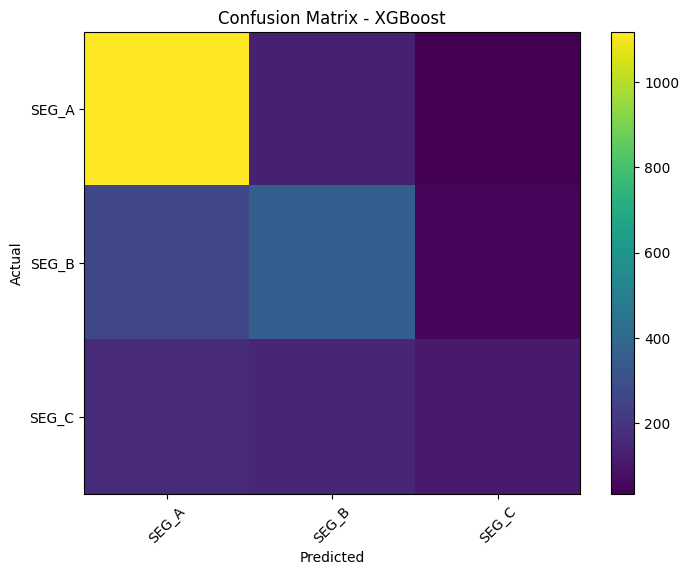

In [445]:
#Visualize the confusion matrix for the original base model
plt.figure(figsize=(8,6))
plt.imshow(cm, aspect="auto")
plt.colorbar()
plt.xticks(range(len(le.classes_)), le.classes_, rotation=45)
plt.yticks(range(len(le.classes_)), le.classes_)
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [446]:
#Feature importance for the original base model
feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

feat_imp.head(20)

,feature,importance
4,ORAL_TRX_mean,0.087698
1,UC_TRX_median,0.069650
59,1960_1980,0.026344
5,IL23_TRX_mean,0.024859
52,STATE_4,0.023650
56,STATE_8,0.022191
0,UC_TRX_mean,0.022105
49,STATE_1,0.021492
54,STATE_6,0.020202
51,STATE_3,0.018960


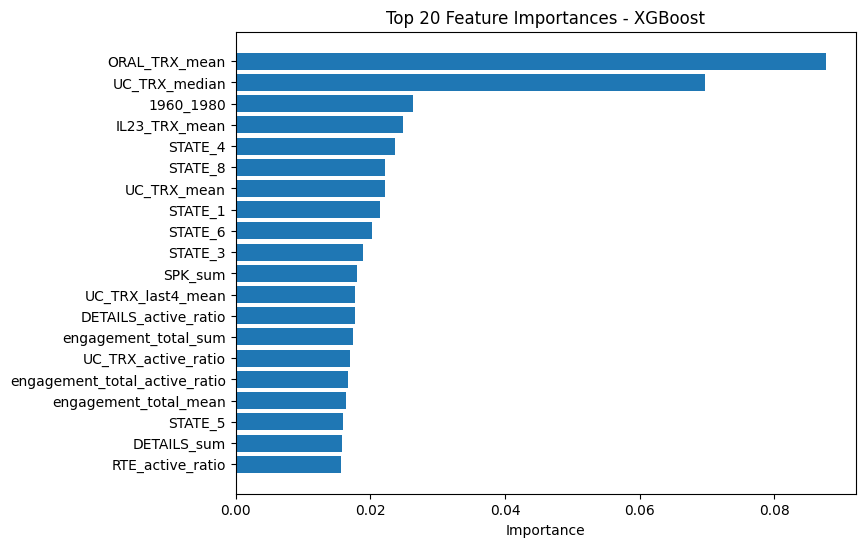

In [447]:
# Visualize feature importance for the original base model
top_n = 20
plt.figure(figsize=(8,6))
plt.barh(feat_imp["feature"].head(top_n)[::-1], feat_imp["importance"].head(top_n)[::-1])
plt.title("Top 20 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.show()

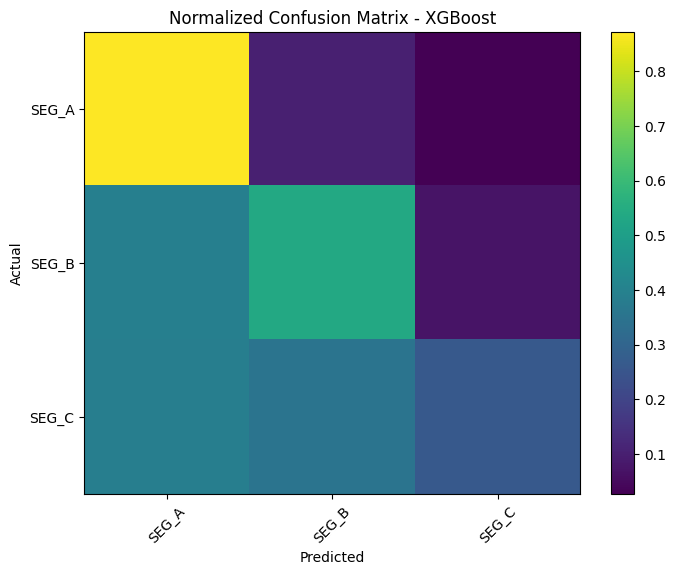

In [448]:
#Visualize the normalized confusion matrix for the original base model
cm = confusion_matrix(y_test, y_pred_base)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8,6))
plt.imshow(cm_norm, aspect="auto")
plt.colorbar()
plt.xticks(range(len(le.classes_)), le.classes_, rotation=45)
plt.yticks(range(len(le.classes_)), le.classes_)
plt.title("Normalized Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Weighted model

In [449]:
# Compute sample weights to handle class imbalance
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

In [450]:
#Train weighted XGBoost model
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y_encoded)),
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_class=3, num_parallel_tree=None, ...)

In [451]:
#Predict with the weighted model
y_pred_weighted = xgb_model.predict(X_test)

In [452]:
#Evaluate the original weighted model on the test set
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_weighted))
print("XGBoost Macro F1:", f1_score(y_test, y_pred_weighted, average="macro"))
print("XGBoost Weighted F1:", f1_score(y_test, y_pred_weighted, average="weighted"))

XGBoost Accuracy: 0.6365546218487395
XGBoost Macro F1: 0.5818419346975001
XGBoost Weighted F1: 0.6422477193407459


In [453]:
#Evaluate the original weighted model on the test set
print(classification_report(y_test, y_pred_weighted, target_names=le.classes_))

              precision    recall  f1-score   support

       SEG_A       0.79      0.73      0.76      1281
       SEG_B       0.52      0.56      0.54       670
       SEG_C       0.42      0.47      0.44       429

    accuracy                           0.64      2380
   macro avg       0.58      0.59      0.58      2380
weighted avg       0.65      0.64      0.64      2380



In [454]:
#Confusion matrix for the original weighted model
cm = confusion_matrix(y_test, y_pred_weighted)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
cm_df

,SEG_A,SEG_B,SEG_C
SEG_A,939,203,139
SEG_B,153,374,143
SEG_C,91,136,202


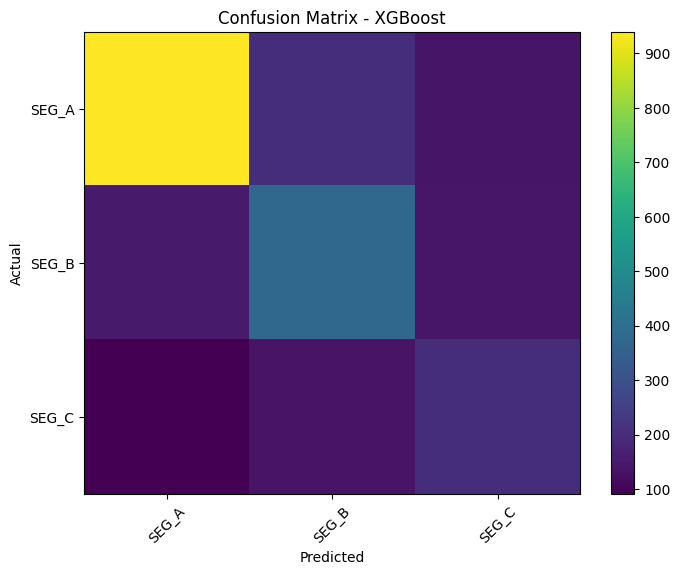

In [455]:
#Visualize the confusion matrix for the original weighted model
plt.figure(figsize=(8,6))
plt.imshow(cm, aspect="auto")
plt.colorbar()
plt.xticks(range(len(le.classes_)), le.classes_, rotation=45)
plt.yticks(range(len(le.classes_)), le.classes_)
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [456]:
#Feature importance for the original weighted model
feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

feat_imp.head(20)

,feature,importance
1,UC_TRX_median,0.065443
4,ORAL_TRX_mean,0.057589
52,STATE_4,0.029016
59,1960_1980,0.028561
49,STATE_1,0.025474
56,STATE_8,0.025003
5,IL23_TRX_mean,0.022822
0,UC_TRX_mean,0.022474
51,STATE_3,0.020402
54,STATE_6,0.020138


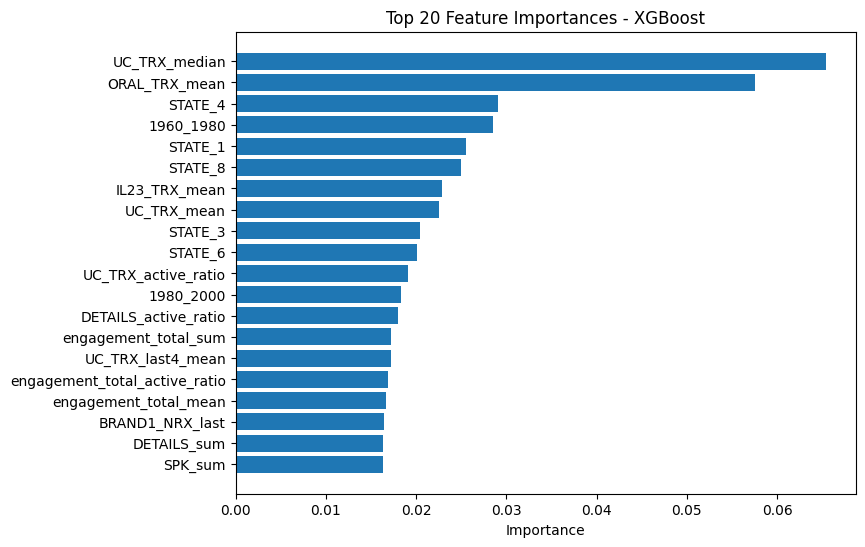

In [457]:
# Visualize feature importance for the original weighted model
top_n = 20
plt.figure(figsize=(8,6))
plt.barh(feat_imp["feature"].head(top_n)[::-1], feat_imp["importance"].head(top_n)[::-1])
plt.title("Top 20 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.show()

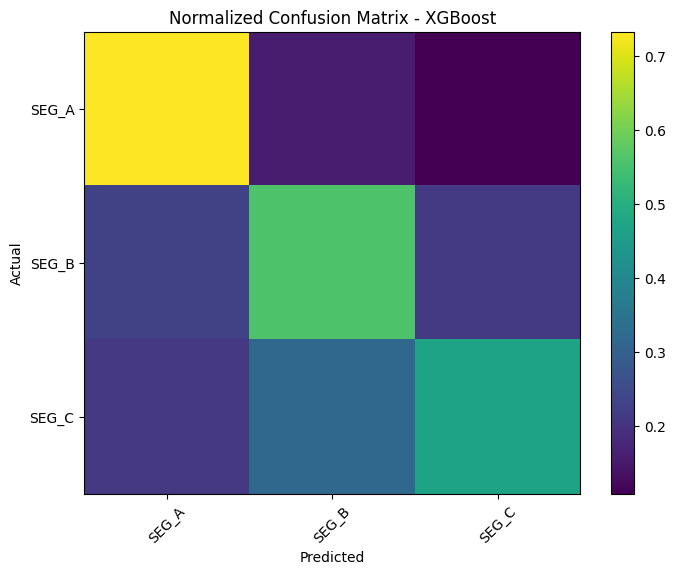

In [458]:
#Visualize the normalized confusion matrix for the original weighted model
cm = confusion_matrix(y_test, y_pred_weighted)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8,6))
plt.imshow(cm_norm, aspect="auto")
plt.colorbar()
plt.xticks(range(len(le.classes_)), le.classes_, rotation=45)
plt.yticks(range(len(le.classes_)), le.classes_)
plt.title("Normalized Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Tuned weighted model

In [459]:
# Initialize the XGBoost classifier with basic parameters
xgb_base = XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y_encoded)),
    random_state=42,
    eval_metric="mlogloss"
)
    
# Define a parameter grid for RandomizedSearchCV
param_dist = {
    "n_estimators": [200, 300, 400, 500, 700,1000],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 2, 5, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

macro_f1_scorer = make_scorer(f1_score, average="macro")

# Perform randomized search with cross-validation to find the best hyperparameters
search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=100,
    scoring=macro_f1_scorer,
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train, sample_weight=sample_weights)

print("Best params:", search.best_params_)
print("Best CV macro F1:", search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


Best params: {'subsample': 0.7, 'reg_lambda': 2, 'reg_alpha': 1, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.7}
Best CV macro F1: 0.5713704848303791


In [460]:
best_params = search.best_params_

In [461]:
# Evaluate the best model on the test set
best_xgb = search.best_estimator_

y_pred_tuned = best_xgb.predict(X_test)

print("Tuned XGBoost Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Tuned XGBoost Macro F1:", f1_score(y_test, y_pred_tuned, average="macro"))
print("Tuned XGBoost Weighted F1:", f1_score(y_test, y_pred_tuned, average="weighted"))

print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))

Tuned XGBoost Accuracy: 0.6323529411764706
Tuned XGBoost Macro F1: 0.5791484692172582
Tuned XGBoost Weighted F1: 0.6388778718655668
              precision    recall  f1-score   support

       SEG_A       0.79      0.73      0.76      1281
       SEG_B       0.52      0.54      0.53       670
       SEG_C       0.41      0.49      0.45       429

    accuracy                           0.63      2380
   macro avg       0.58      0.59      0.58      2380
weighted avg       0.65      0.63      0.64      2380



In [462]:
#Confusion matrix for the tuned model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
cm_tuned_df = pd.DataFrame(cm_tuned, index=le.classes_, columns=le.classes_)
cm_tuned_df

,SEG_A,SEG_B,SEG_C
SEG_A,932,202,147
SEG_B,152,364,154
SEG_C,91,129,209


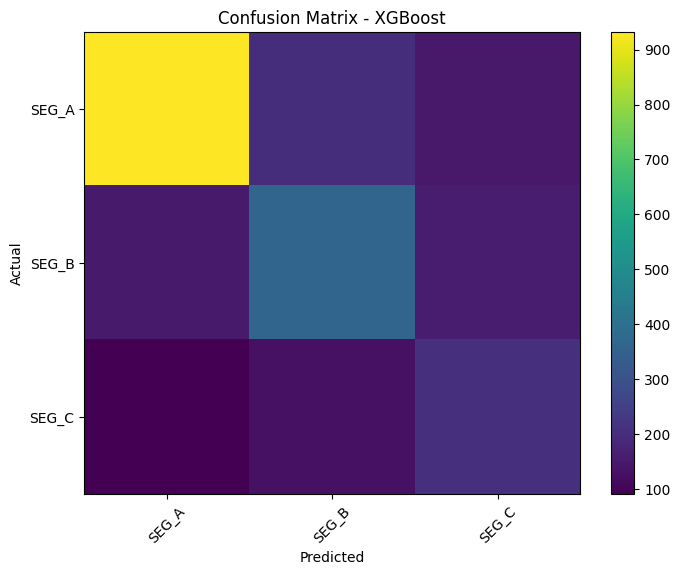

In [463]:
#Visualize the confusion matrix for the original tuned model
plt.figure(figsize=(8,6))
plt.imshow(cm_tuned, aspect="auto")
plt.colorbar()
plt.xticks(range(len(le.classes_)), le.classes_, rotation=45)
plt.yticks(range(len(le.classes_)), le.classes_)
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [464]:
#Feature importance for the tuned model
feat_imp_tuned = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_xgb.feature_importances_
}).sort_values("importance", ascending=False)

feat_imp_tuned.head(20)

,feature,importance
4,ORAL_TRX_mean,0.080082
1,UC_TRX_median,0.071941
0,UC_TRX_mean,0.032736
59,1960_1980,0.031810
52,STATE_4,0.028935
5,IL23_TRX_mean,0.026701
49,STATE_1,0.025508
56,STATE_8,0.023058
3,UC_TRX_active_ratio,0.020671
25,DETAILS_active_ratio,0.018294


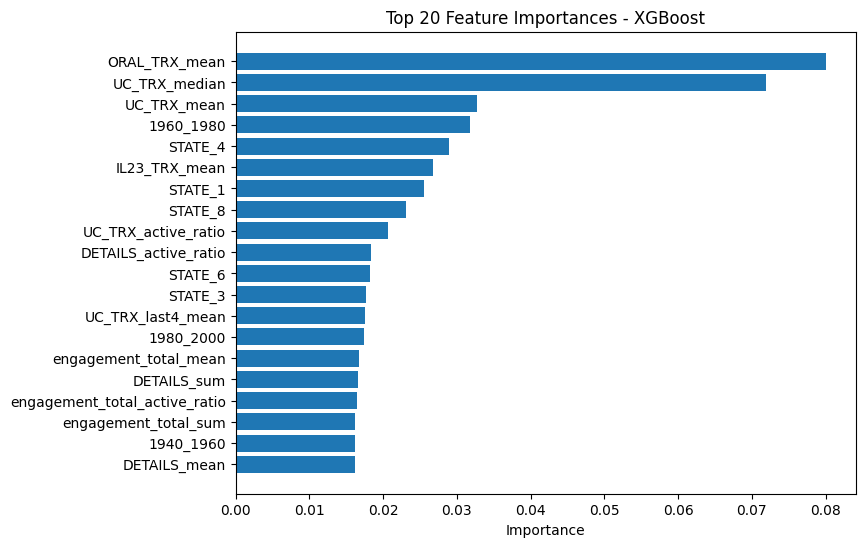

In [465]:
# Visualize feature importance for the original tuned model
top_n = 20
plt.figure(figsize=(8,6))
plt.barh(feat_imp_tuned["feature"].head(top_n)[::-1], feat_imp_tuned["importance"].head(top_n)[::-1])
plt.title("Top 20 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.show()

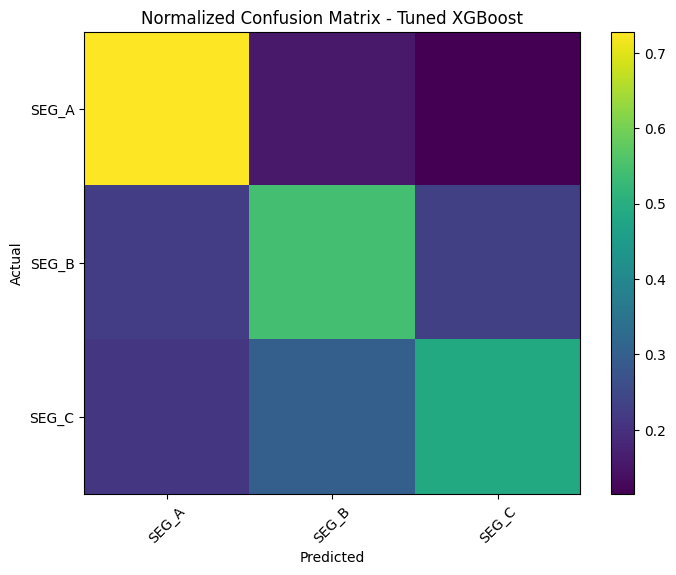

In [466]:
#Visualize the normalized confusion matrix for the tuned model
cm_tuned_norm = cm_tuned / cm_tuned.sum(axis=1, keepdims=True)

plt.figure(figsize=(8,6))
plt.imshow(cm_tuned_norm, aspect="auto")
plt.colorbar()
plt.xticks(range(len(le.classes_)), le.classes_, rotation=45)
plt.yticks(range(len(le.classes_)), le.classes_)
plt.title("Normalized Confusion Matrix - Tuned XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Comparison of all the models

In [467]:
#Show accuracy and F1 scores for all models in a single table
comparison_results = pd.DataFrame({
    "model": ["Dummy", "XGB_base", "XGB_weighted", "XGB_weighted_tuned"],
    "accuracy": [
        accuracy_score(y_test, dummy_preds),
        accuracy_score(y_test, y_pred_base),
        accuracy_score(y_test, y_pred_weighted),
        accuracy_score(y_test, y_pred_tuned)
    ],
    "macro_f1": [
        f1_score(y_test, dummy_preds, average="macro"),
        f1_score(y_test, y_pred_base, average="macro"),
        f1_score(y_test, y_pred_weighted, average="macro"),
        f1_score(y_test, y_pred_tuned, average="macro")
    ],
    "weighted_f1": [
        f1_score(y_test, dummy_preds, average="weighted"),
        f1_score(y_test, y_pred_base, average="weighted"),
        f1_score(y_test, y_pred_weighted, average="weighted"),
        f1_score(y_test, y_pred_tuned, average="weighted")
    ]
})

comparison_results

,model,accuracy,macro_f1,weighted_f1
0,Dummy,0.538235,0.233270,0.376662
1,XGB_base,0.667227,0.565960,0.644438
2,XGB_weighted,0.636555,0.581842,0.642248
3,XGB_weighted_tuned,0.632353,0.579148,0.638878
